# 02_taker_execution_simulator

## Goal

This notebook builds a first-pass **taker execution simulator** using reconstructed L2 top-N snapshots.

We assume the input comes from `01_reconstruct_l2_book.ipynb`, for example:

- `book_top20_sampled.parquet`
- or a filtered subset such as one clean day of `topn_all`

## Scope of version 1

This notebook focuses on:

- taker buy simulation
- taker sell simulation
- VWAP / average fill price
- number of levels swept
- slippage vs mid
- slippage vs best ask / best bid
- simple execution cost curves

## Out of scope for version 1

This notebook does **not** yet implement:

- maker / passive execution
- queue position model
- latency model
- strategy backtest integration

Those can come later.

In [2]:
# =========================================
# 1. Imports
# =========================================

from pathlib import Path
from typing import List, Dict, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Configuration

Edit this section first.

This notebook is intended to run on a **clean day** first, before scaling to more dates.

In [10]:
# =========================================
# 1b. User Config
# =========================================

from pathlib import Path

RECON_OUTPUT_ROOT = Path("/Volumes/profit/bitcoin_ticks/reconstructed_outputs/spot/btcusdt")

# Choose one clean date first
TARGET_DATE = "20251101"

TOP_N = 20
TEST_QTYS = [0.001, 0.002, 0.005, 0.01, 0.02, 0.05]

FIGSIZE = (12, 5)

In [11]:
print("RECON_OUTPUT_ROOT exists:", RECON_OUTPUT_ROOT.exists())
print([p.name for p in sorted(RECON_OUTPUT_ROOT.glob("*"))[:20]])

RECON_OUTPUT_ROOT exists: True
['book_event_summary_20251030_00.parquet', 'book_event_summary_20251030_01.parquet', 'book_event_summary_20251030_02.parquet', 'book_event_summary_20251030_03.parquet', 'book_event_summary_20251030_04.parquet', 'book_event_summary_20251030_05.parquet', 'book_event_summary_20251030_06.parquet', 'book_event_summary_20251030_07.parquet', 'book_event_summary_20251030_08.parquet', 'book_event_summary_20251030_09.parquet', 'book_event_summary_20251030_10.parquet', 'book_event_summary_20251030_11.parquet', 'book_event_summary_20251030_12.parquet', 'book_event_summary_20251030_13.parquet', 'book_event_summary_20251030_14.parquet', 'book_event_summary_20251030_15.parquet', 'book_event_summary_20251030_16.parquet', 'book_event_summary_20251030_17.parquet', 'book_event_summary_20251030_18.parquet', 'book_event_summary_20251030_19.parquet']


# 2. Load top-N book snapshots

We load the reconstructed top-N snapshots and filter to a clean date.

This notebook uses `topn_all`-style output with columns like:

- `bid_px_1 ... bid_px_20`
- `bid_sz_1 ... bid_sz_20`
- `ask_px_1 ... ask_px_20`
- `ask_sz_1 ... ask_sz_20`

In [12]:
# =========================================
# 2. Discover hourly top20 parquet files
# =========================================

def discover_topn_parquet_files(output_root: Path) -> pd.DataFrame:
    rows = []

    for p in sorted(output_root.glob("book_top20_sampled_*.parquet")):
        name = p.name
        # expected pattern: book_top20_sampled_YYYYMMDD_HH.parquet
        stem = name.replace(".parquet", "")
        parts = stem.split("_")

        if len(parts) < 5:
            continue

        date_str = parts[-2]
        hour_str = parts[-1]

        if not (date_str.isdigit() and len(date_str) == 8):
            continue
        if not (hour_str.isdigit() and len(hour_str) == 2):
            continue

        rows.append({
            "path": str(p),
            "date": date_str,
            "hour": hour_str,
            "session_id": f"{date_str}_{hour_str}",
        })

    return pd.DataFrame(rows)

topn_file_map = discover_topn_parquet_files(RECON_OUTPUT_ROOT)

print("RECON_OUTPUT_ROOT:", RECON_OUTPUT_ROOT)
print("n hourly top20 parquet files:", len(topn_file_map))
display(topn_file_map.head(20))

RECON_OUTPUT_ROOT: /Volumes/profit/bitcoin_ticks/reconstructed_outputs/spot/btcusdt
n hourly top20 parquet files: 136


,path,date,hour,session_id
0,/Volumes/profit/bitcoin_ticks/reconstructed_ou...,20251030,00,20251030_00
1,/Volumes/profit/bitcoin_ticks/reconstructed_ou...,20251030,01,20251030_01
2,/Volumes/profit/bitcoin_ticks/reconstructed_ou...,20251030,02,20251030_02
3,/Volumes/profit/bitcoin_ticks/reconstructed_ou...,20251030,03,20251030_03
4,/Volumes/profit/bitcoin_ticks/reconstructed_ou...,20251030,04,20251030_04
5,/Volumes/profit/bitcoin_ticks/reconstructed_ou...,20251030,05,20251030_05
6,/Volumes/profit/bitcoin_ticks/reconstructed_ou...,20251030,06,20251030_06
7,/Volumes/profit/bitcoin_ticks/reconstructed_ou...,20251030,07,20251030_07
8,/Volumes/profit/bitcoin_ticks/reconstructed_ou...,20251030,08,20251030_08
9,/Volumes/profit/bitcoin_ticks/reconstructed_ou...,20251030,09,20251030_09


In [13]:
# =========================================
# 2b. Load one clean day of top20 snapshots
# =========================================

topn_day_files = topn_file_map[topn_file_map["date"] == TARGET_DATE].copy()

print("TARGET_DATE:", TARGET_DATE)
print("n files for date:", len(topn_day_files))
display(topn_day_files.head(10))

topn_day = pd.concat(
    [pd.read_parquet(p) for p in topn_day_files["path"]],
    ignore_index=True
) if len(topn_day_files) > 0 else pd.DataFrame()

print("topn_day shape:", topn_day.shape)

if len(topn_day) > 0:
    print("n sessions:", topn_day["session_id"].nunique())
    display(topn_day.head(3))

TARGET_DATE: 20251101
n files for date: 24


,path,date,hour,session_id
48,/Volumes/profit/bitcoin_ticks/reconstructed_ou...,20251101,00,20251101_00
49,/Volumes/profit/bitcoin_ticks/reconstructed_ou...,20251101,01,20251101_01
50,/Volumes/profit/bitcoin_ticks/reconstructed_ou...,20251101,02,20251101_02
51,/Volumes/profit/bitcoin_ticks/reconstructed_ou...,20251101,03,20251101_03
52,/Volumes/profit/bitcoin_ticks/reconstructed_ou...,20251101,04,20251101_04
53,/Volumes/profit/bitcoin_ticks/reconstructed_ou...,20251101,05,20251101_05
54,/Volumes/profit/bitcoin_ticks/reconstructed_ou...,20251101,06,20251101_06
55,/Volumes/profit/bitcoin_ticks/reconstructed_ou...,20251101,07,20251101_07
56,/Volumes/profit/bitcoin_ticks/reconstructed_ou...,20251101,08,20251101_08
57,/Volumes/profit/bitcoin_ticks/reconstructed_ou...,20251101,09,20251101_09


topn_day shape: (89723, 88)
n sessions: 24


,event_time,last_update_id,bid_px_1,bid_sz_1,ask_px_1,ask_sz_1,bid_px_2,bid_sz_2,ask_px_2,ask_sz_2,...,bid_px_20,bid_sz_20,ask_px_20,ask_sz_20,date,hour,session_id,segment_id,snapshot_file,source_file
0,1761955463714,79468211418,109453.58,0.00141,109453.59,9.12215,109453.57,0.00060,109453.66,0.01798,...,109446.90,0.00005,109458.30,0.00006,20251101,00,20251101_00,0,/Volumes/Profit/bitcoin_ticks/spot/btcusdt/202...,/Volumes/Profit/bitcoin_ticks/spot/btcusdt/202...
1,1761955464714,79468212063,109451.37,0.05894,109451.38,9.34931,109451.36,0.00055,109451.46,0.00010,...,109445.14,0.00006,109457.93,2.82858,20251101,00,20251101_00,0,/Volumes/Profit/bitcoin_ticks/spot/btcusdt/202...,/Volumes/Profit/bitcoin_ticks/spot/btcusdt/202...
2,1761955465714,79468212199,109451.37,0.06013,109451.38,9.64834,109451.36,0.00065,109451.46,0.00010,...,109445.54,0.00182,109457.94,0.17252,20251101,00,20251101_00,0,/Volumes/Profit/bitcoin_ticks/spot/btcusdt/202...,/Volumes/Profit/bitcoin_ticks/spot/btcusdt/202...


# 3. Basic helper functions

We first define helpers to extract book levels from a single row.

A row represents one sampled snapshot of the L2 order book.

In [14]:
# =========================================
# 3. Helpers to extract levels
# =========================================

def extract_bid_levels(row: pd.Series, n: int = 20) -> List[Tuple[float, float]]:
    levels = []
    for i in range(1, n + 1):
        px = row.get(f"bid_px_{i}", np.nan)
        sz = row.get(f"bid_sz_{i}", np.nan)
        if pd.notna(px) and pd.notna(sz) and sz > 0:
            levels.append((float(px), float(sz)))
    return levels

def extract_ask_levels(row: pd.Series, n: int = 20) -> List[Tuple[float, float]]:
    levels = []
    for i in range(1, n + 1):
        px = row.get(f"ask_px_{i}", np.nan)
        sz = row.get(f"ask_sz_{i}", np.nan)
        if pd.notna(px) and pd.notna(sz) and sz > 0:
            levels.append((float(px), float(sz)))
    return levels

def row_mid(row: pd.Series) -> float:
    best_bid = row.get("bid_px_1", np.nan)
    best_ask = row.get("ask_px_1", np.nan)
    if pd.isna(best_bid) or pd.isna(best_ask):
        return np.nan
    return 0.5 * (best_bid + best_ask)

def row_spread(row: pd.Series) -> float:
    best_bid = row.get("bid_px_1", np.nan)
    best_ask = row.get("ask_px_1", np.nan)
    if pd.isna(best_bid) or pd.isna(best_ask):
        return np.nan
    return best_ask - best_bid

# 4. Taker simulation core

## Market buy
A taker buy consumes liquidity from the ask side, from best ask upward.

## Market sell
A taker sell consumes liquidity from the bid side, from best bid downward.

In [15]:
# =========================================
# 4. Simulate taker buy
# =========================================

def simulate_taker_buy(row: pd.Series, qty: float, n: int = 20) -> Dict:
    asks = extract_ask_levels(row, n=n)

    remaining = float(qty)
    filled = 0.0
    notional = 0.0
    levels_used = []

    for px, avail in asks:
        if remaining <= 0:
            break

        take = min(remaining, avail)
        filled += take
        notional += take * px
        levels_used.append((px, take))
        remaining -= take

    avg_fill_price = notional / filled if filled > 0 else np.nan

    best_ask = row.get("ask_px_1", np.nan)
    mid = row_mid(row)

    slippage_vs_best_ask_bps = np.nan
    slippage_vs_mid_bps = np.nan

    if filled > 0 and pd.notna(best_ask):
        slippage_vs_best_ask_bps = 1e4 * (avg_fill_price / best_ask - 1.0)

    if filled > 0 and pd.notna(mid):
        slippage_vs_mid_bps = 1e4 * (avg_fill_price / mid - 1.0)

    return {
        "side": "buy",
        "event_time": row.get("event_time"),
        "date": row.get("date"),
        "session_id": row.get("session_id"),
        "target_qty": qty,
        "filled_qty": filled,
        "unfilled_qty": remaining,
        "fully_filled": remaining <= 1e-12,
        "avg_fill_price": avg_fill_price,
        "notional": notional,
        "best_ask": best_ask,
        "mid": mid,
        "n_levels_swept": len(levels_used),
        "levels_used": levels_used,
        "slippage_vs_best_ask_bps": slippage_vs_best_ask_bps,
        "slippage_vs_mid_bps": slippage_vs_mid_bps,
    }

In [16]:
# =========================================
# 4b. Simulate taker sell
# =========================================

def simulate_taker_sell(row: pd.Series, qty: float, n: int = 20) -> Dict:
    bids = extract_bid_levels(row, n=n)

    remaining = float(qty)
    filled = 0.0
    notional = 0.0
    levels_used = []

    for px, avail in bids:
        if remaining <= 0:
            break

        take = min(remaining, avail)
        filled += take
        notional += take * px
        levels_used.append((px, take))
        remaining -= take

    avg_fill_price = notional / filled if filled > 0 else np.nan

    best_bid = row.get("bid_px_1", np.nan)
    mid = row_mid(row)

    slippage_vs_best_bid_bps = np.nan
    slippage_vs_mid_bps = np.nan

    if filled > 0 and pd.notna(best_bid):
        slippage_vs_best_bid_bps = 1e4 * (1.0 - avg_fill_price / best_bid)

    if filled > 0 and pd.notna(mid):
        slippage_vs_mid_bps = 1e4 * (1.0 - avg_fill_price / mid)

    return {
        "side": "sell",
        "event_time": row.get("event_time"),
        "date": row.get("date"),
        "session_id": row.get("session_id"),
        "target_qty": qty,
        "filled_qty": filled,
        "unfilled_qty": remaining,
        "fully_filled": remaining <= 1e-12,
        "avg_fill_price": avg_fill_price,
        "notional": notional,
        "best_bid": best_bid,
        "mid": mid,
        "n_levels_swept": len(levels_used),
        "levels_used": levels_used,
        "slippage_vs_best_bid_bps": slippage_vs_best_bid_bps,
        "slippage_vs_mid_bps": slippage_vs_mid_bps,
    }

# 5. Quick single-row sanity checks

Before running large experiments, we sanity-check one snapshot.

In [17]:
# =========================================
# 5. Single-row sanity test
# =========================================

row0 = topn_day.iloc[0]

print("event_time:", row0["event_time"])
print("session_id:", row0["session_id"])
print("mid:", row_mid(row0))
print("spread:", row_spread(row0))

buy_test = simulate_taker_buy(row0, qty=0.005, n=TOP_N)
sell_test = simulate_taker_sell(row0, qty=0.005, n=TOP_N)

print("\nBuy test:")
display(pd.Series({k: v for k, v in buy_test.items() if k != "levels_used"}))

print("\nSell test:")
display(pd.Series({k: v for k, v in sell_test.items() if k != "levels_used"}))

event_time: 1761955463714
session_id: 20251101_00
mid: 109453.58499999999
spread: 0.00999999999476131

Buy test:


side                                  buy
event_time                  1761955463714
date                             20251101
session_id                    20251101_00
target_qty                          0.005
filled_qty                          0.005
unfilled_qty                          0.0
fully_filled                         True
avg_fill_price                  109453.59
notional                        547.26795
best_ask                        109453.59
mid                            109453.585
n_levels_swept                          1
slippage_vs_best_ask_bps              0.0
slippage_vs_mid_bps              0.000457
dtype: object


Sell test:


side                                 sell
event_time                  1761955463714
date                             20251101
session_id                    20251101_00
target_qty                          0.005
filled_qty                          0.005
unfilled_qty                          0.0
fully_filled                         True
avg_fill_price                109452.5015
notional                       547.262508
best_bid                        109453.58
mid                            109453.585
n_levels_swept                          7
slippage_vs_best_bid_bps         0.098535
slippage_vs_mid_bps              0.098992
dtype: object

# 6. Batch simulation over many snapshots

Now we simulate execution across many snapshots for a grid of order sizes.

Version 1 uses:

- all sampled snapshots from one day
- a list of fixed quantities in base asset units

In [18]:
# =========================================
# 6. Run batch simulations
# =========================================

def run_taker_experiments(
    df: pd.DataFrame,
    qtys: List[float],
    side: str = "buy",
    n: int = 20,
    max_rows: Optional[int] = None,
) -> pd.DataFrame:
    if max_rows is not None:
        df = df.iloc[:max_rows].copy()

    out = []

    for qty in qtys:
        for _, row in df.iterrows():
            if side == "buy":
                res = simulate_taker_buy(row, qty=qty, n=n)
            elif side == "sell":
                res = simulate_taker_sell(row, qty=qty, n=n)
            else:
                raise ValueError("side must be 'buy' or 'sell'")

            out.append(res)

    return pd.DataFrame(out)

In [19]:
# To keep runtime manageable at first, optionally use a subset
# You can set EXPERIMENT_DF = topn_day.copy() later if desired.

EXPERIMENT_DF = topn_day.copy()

print("experiment rows:", len(EXPERIMENT_DF))

experiment rows: 89723


In [20]:
buy_results = run_taker_experiments(
    df=EXPERIMENT_DF,
    qtys=TEST_QTYS,
    side="buy",
    n=TOP_N,
)

sell_results = run_taker_experiments(
    df=EXPERIMENT_DF,
    qtys=TEST_QTYS,
    side="sell",
    n=TOP_N,
)

print("buy_results shape :", buy_results.shape)
print("sell_results shape:", sell_results.shape)

buy_results shape : (538338, 16)
sell_results shape: (538338, 16)


# 7. Aggregate execution statistics

We summarize:

- fill rate
- average levels swept
- average slippage
- average notional

In [21]:
# =========================================
# 7. Aggregate metrics
# =========================================

def summarize_execution_results(results: pd.DataFrame, side: str) -> pd.DataFrame:
    out = results.groupby("target_qty").agg(
        n_obs=("target_qty", "size"),
        full_fill_rate=("fully_filled", "mean"),
        avg_filled_qty=("filled_qty", "mean"),
        avg_notional=("notional", "mean"),
        avg_levels_swept=("n_levels_swept", "mean"),
        med_levels_swept=("n_levels_swept", "median"),
        avg_slippage_vs_mid_bps=("slippage_vs_mid_bps", "mean"),
    ).reset_index()

    if side == "buy":
        extra = results.groupby("target_qty")["slippage_vs_best_ask_bps"].mean().reset_index(name="avg_slippage_vs_touch_bps")
    else:
        extra = results.groupby("target_qty")["slippage_vs_best_bid_bps"].mean().reset_index(name="avg_slippage_vs_touch_bps")

    out = out.merge(extra, on="target_qty", how="left")
    out["side"] = side
    return out

buy_summary = summarize_execution_results(buy_results, side="buy")
sell_summary = summarize_execution_results(sell_results, side="sell")

display(buy_summary)
display(sell_summary)

,target_qty,n_obs,full_fill_rate,avg_filled_qty,avg_notional,avg_levels_swept,med_levels_swept,avg_slippage_vs_mid_bps,avg_slippage_vs_touch_bps,side
0,0.001,89723,1.000000,0.001000,110.087908,1.001304,1.0,0.000495,0.000014,buy
1,0.002,89723,1.000000,0.002000,220.175816,1.003711,1.0,0.000512,0.000032,buy
2,0.005,89723,0.999989,0.005000,550.436378,1.022124,1.0,0.000635,0.000154,buy
3,0.010,89723,0.999989,0.010000,1100.869827,1.058993,1.0,0.001020,0.000540,buy
4,0.020,89723,0.999565,0.019998,2201.557519,1.122265,1.0,0.001792,0.001312,buy
5,0.050,89723,0.996779,0.049943,5498.174562,1.267200,1.0,0.003547,0.003067,buy


,target_qty,n_obs,full_fill_rate,avg_filled_qty,avg_notional,avg_levels_swept,med_levels_swept,avg_slippage_vs_mid_bps,avg_slippage_vs_touch_bps,side
0,0.001,89723,1.000000,0.001000,110.087897,1.001438,1.0,0.000488,0.000008,sell
1,0.002,89723,1.000000,0.002000,220.175793,1.005562,1.0,0.000508,0.000028,sell
2,0.005,89723,1.000000,0.005000,550.439469,1.041873,1.0,0.000769,0.000289,sell
3,0.010,89723,0.999967,0.010000,1100.867170,1.128518,1.0,0.001613,0.001133,sell
4,0.020,89723,0.998830,0.019996,2201.307446,1.262162,1.0,0.003425,0.002944,sell
5,0.050,89723,0.993892,0.049884,5491.651108,1.507038,1.0,0.006900,0.006420,sell


# 8. Plot cost curves

These are the main first-pass outputs:

- quantity vs slippage
- quantity vs levels swept
- quantity vs fill rate

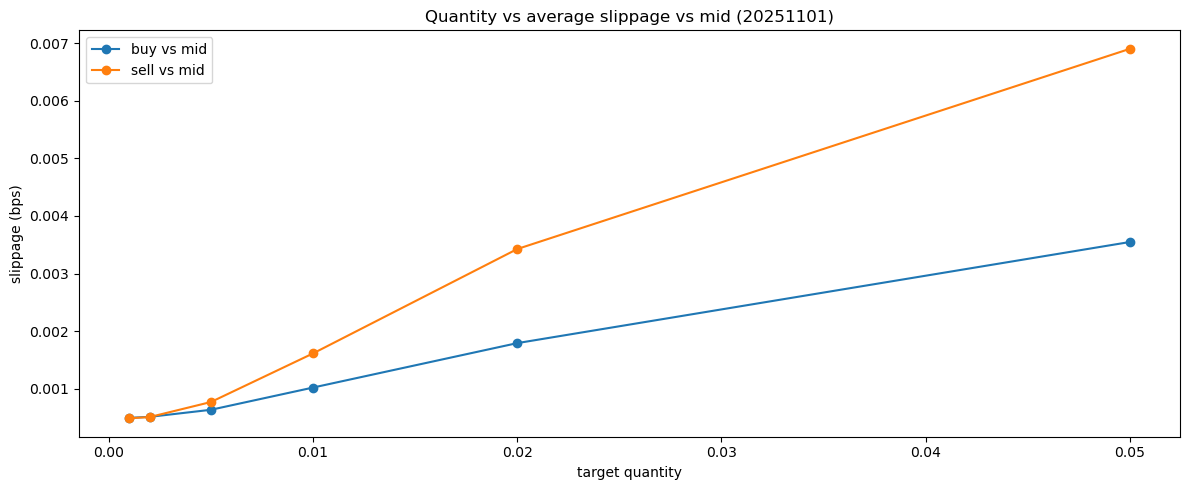

In [22]:
# =========================================
# 8a. Quantity vs slippage
# =========================================

fig, ax = plt.subplots(figsize=FIGSIZE)
ax.plot(buy_summary["target_qty"], buy_summary["avg_slippage_vs_mid_bps"], marker="o", label="buy vs mid")
ax.plot(sell_summary["target_qty"], sell_summary["avg_slippage_vs_mid_bps"], marker="o", label="sell vs mid")
ax.set_title(f"Quantity vs average slippage vs mid ({TARGET_DATE})")
ax.set_xlabel("target quantity")
ax.set_ylabel("slippage (bps)")
ax.legend()
plt.tight_layout()
plt.show()

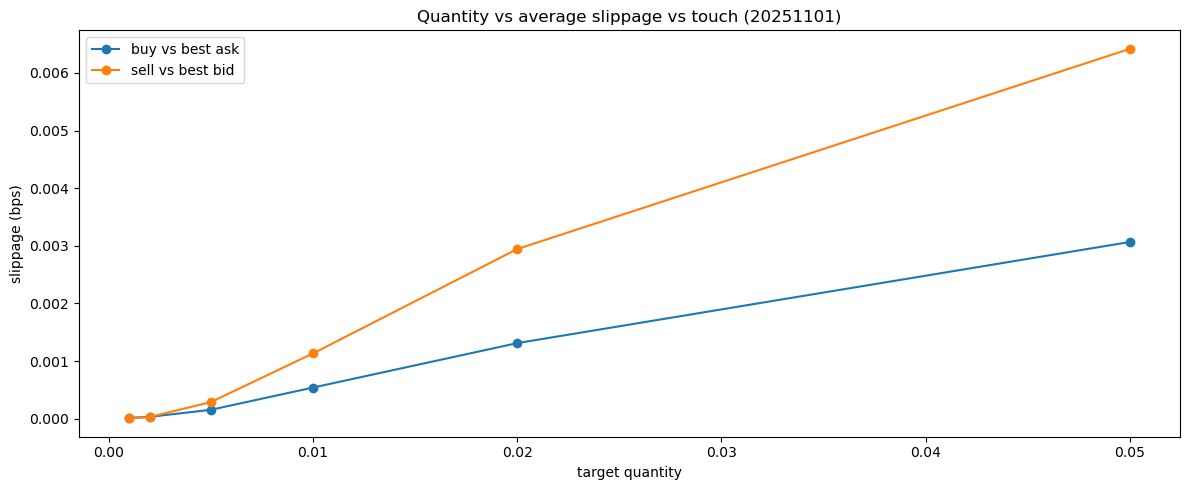

In [23]:
# =========================================
# 8b. Quantity vs touch slippage
# =========================================

fig, ax = plt.subplots(figsize=FIGSIZE)
ax.plot(buy_summary["target_qty"], buy_summary["avg_slippage_vs_touch_bps"], marker="o", label="buy vs best ask")
ax.plot(sell_summary["target_qty"], sell_summary["avg_slippage_vs_touch_bps"], marker="o", label="sell vs best bid")
ax.set_title(f"Quantity vs average slippage vs touch ({TARGET_DATE})")
ax.set_xlabel("target quantity")
ax.set_ylabel("slippage (bps)")
ax.legend()
plt.tight_layout()
plt.show()

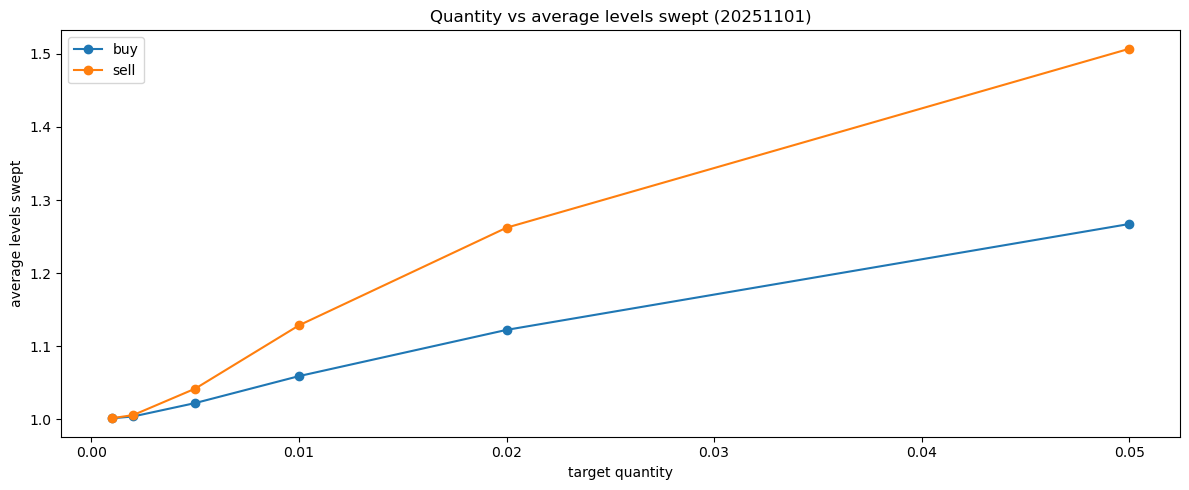

In [24]:
# =========================================
# 8c. Quantity vs levels swept
# =========================================

fig, ax = plt.subplots(figsize=FIGSIZE)
ax.plot(buy_summary["target_qty"], buy_summary["avg_levels_swept"], marker="o", label="buy")
ax.plot(sell_summary["target_qty"], sell_summary["avg_levels_swept"], marker="o", label="sell")
ax.set_title(f"Quantity vs average levels swept ({TARGET_DATE})")
ax.set_xlabel("target quantity")
ax.set_ylabel("average levels swept")
ax.legend()
plt.tight_layout()
plt.show()

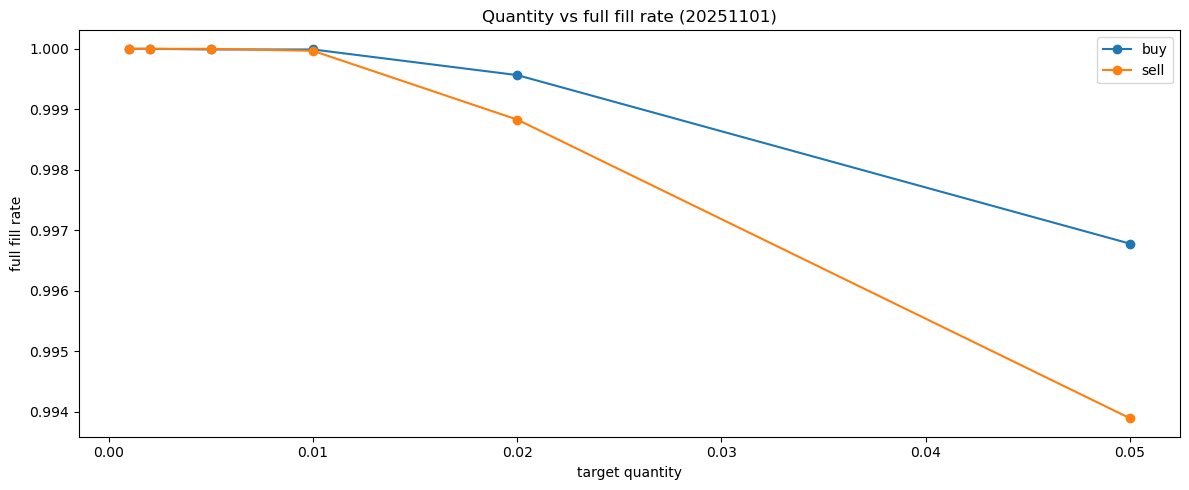

In [25]:
# =========================================
# 8d. Quantity vs fill rate
# =========================================

fig, ax = plt.subplots(figsize=FIGSIZE)
ax.plot(buy_summary["target_qty"], buy_summary["full_fill_rate"], marker="o", label="buy")
ax.plot(sell_summary["target_qty"], sell_summary["full_fill_rate"], marker="o", label="sell")
ax.set_title(f"Quantity vs full fill rate ({TARGET_DATE})")
ax.set_xlabel("target quantity")
ax.set_ylabel("full fill rate")
ax.legend()
plt.tight_layout()
plt.show()

# 9. Session-level comparison

Execution cost may vary by session / hour.  
We compute a simple per-session view for selected quantities.

In [26]:
# =========================================
# 9. Session-level summary
# =========================================

FOCUS_QTY = TEST_QTYS[min(2, len(TEST_QTYS)-1)]  # pick a mid-sized test qty

buy_focus = buy_results[buy_results["target_qty"] == FOCUS_QTY].copy()
sell_focus = sell_results[sell_results["target_qty"] == FOCUS_QTY].copy()

buy_session_summary = buy_focus.groupby("session_id").agg(
    avg_slippage_vs_mid_bps=("slippage_vs_mid_bps", "mean"),
    avg_levels_swept=("n_levels_swept", "mean"),
    full_fill_rate=("fully_filled", "mean"),
).reset_index()

sell_session_summary = sell_focus.groupby("session_id").agg(
    avg_slippage_vs_mid_bps=("slippage_vs_mid_bps", "mean"),
    avg_levels_swept=("n_levels_swept", "mean"),
    full_fill_rate=("fully_filled", "mean"),
).reset_index()

display(buy_session_summary.head(20))
display(sell_session_summary.head(20))

,session_id,avg_slippage_vs_mid_bps,avg_levels_swept,full_fill_rate
0,20251101_00,0.000576,1.015873,1.000000
1,20251101_01,0.000544,1.021949,1.000000
2,20251101_02,0.000559,1.016053,1.000000
3,20251101_03,0.000731,1.012702,1.000000
4,20251101_04,0.000609,1.019169,1.000000
5,20251101_05,0.000634,1.033732,1.000000
6,20251101_06,0.000613,1.022435,1.000000
7,20251101_07,0.000757,1.037058,1.000000
8,20251101_08,0.000707,1.025140,1.000000
9,20251101_09,0.000633,1.023112,0.999718


,session_id,avg_slippage_vs_mid_bps,avg_levels_swept,full_fill_rate
0,20251101_00,0.000740,1.048899,1.0
1,20251101_01,0.000871,1.085184,1.0
2,20251101_02,0.000836,1.075000,1.0
3,20251101_03,0.001760,1.136809,1.0
4,20251101_04,0.001537,1.131257,1.0
5,20251101_05,0.000965,1.053047,1.0
6,20251101_06,0.000636,1.027907,1.0
7,20251101_07,0.000568,1.022400,1.0
8,20251101_08,0.000645,1.021788,1.0
9,20251101_09,0.000562,1.013529,1.0


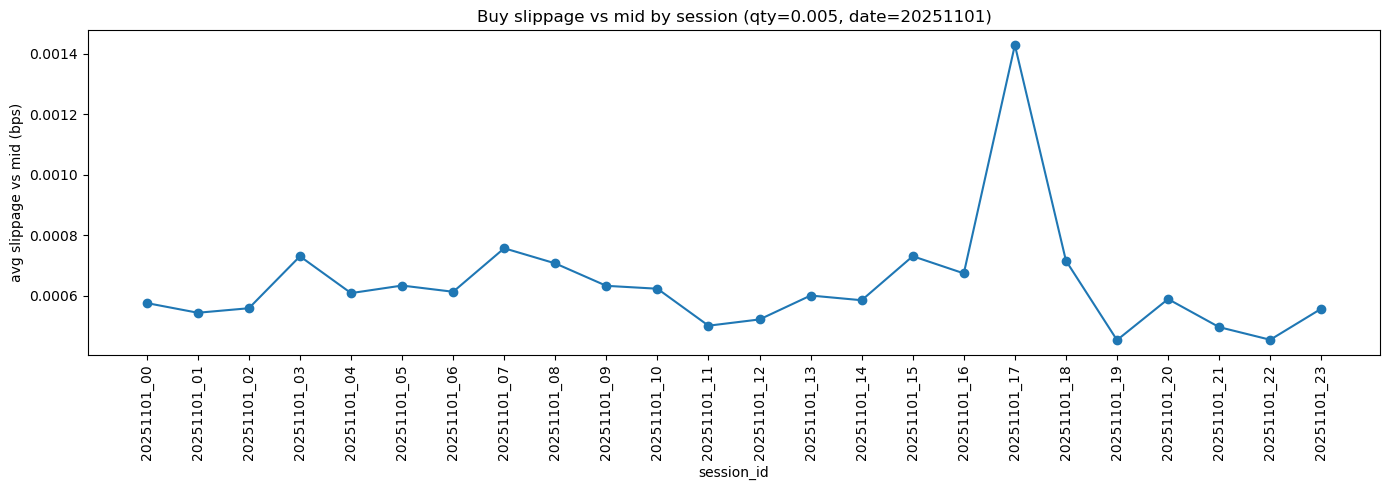

In [27]:
# Plot buy slippage by session

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(buy_session_summary["session_id"], buy_session_summary["avg_slippage_vs_mid_bps"], marker="o")
ax.set_title(f"Buy slippage vs mid by session (qty={FOCUS_QTY}, date={TARGET_DATE})")
ax.set_xlabel("session_id")
ax.set_ylabel("avg slippage vs mid (bps)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# 10. Optional: fixed notional execution

Sometimes it is more natural to specify a trade in quote currency notional rather than base quantity.

Version 1 implements a simple helper:
- convert desired notional to approximate base quantity using mid
- then run the taker simulator

In [28]:
# =========================================
# 10. Fixed notional helper
# =========================================

def approx_qty_from_notional(row: pd.Series, notional: float) -> float:
    mid = row_mid(row)
    if pd.isna(mid) or mid <= 0:
        return np.nan
    return float(notional / mid)

def simulate_taker_buy_notional(row: pd.Series, notional: float, n: int = 20) -> Dict:
    qty = approx_qty_from_notional(row, notional)
    res = simulate_taker_buy(row, qty=qty, n=n)
    res["target_notional"] = notional
    return res

def simulate_taker_sell_notional(row: pd.Series, notional: float, n: int = 20) -> Dict:
    qty = approx_qty_from_notional(row, notional)
    res = simulate_taker_sell(row, qty=qty, n=n)
    res["target_notional"] = notional
    return res

# 11. Save experiment outputs

We save:

- raw buy results
- raw sell results
- aggregated buy summary
- aggregated sell summary

In [29]:
# =========================================
# 11. Save outputs
# =========================================

EXEC_OUTPUT_ROOT = RECON_OUTPUT_ROOT / "execution_outputs"
EXEC_OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

buy_results.to_parquet(EXEC_OUTPUT_ROOT / f"buy_results_{TARGET_DATE}.parquet", index=False)
sell_results.to_parquet(EXEC_OUTPUT_ROOT / f"sell_results_{TARGET_DATE}.parquet", index=False)
buy_summary.to_parquet(EXEC_OUTPUT_ROOT / f"buy_summary_{TARGET_DATE}.parquet", index=False)
sell_summary.to_parquet(EXEC_OUTPUT_ROOT / f"sell_summary_{TARGET_DATE}.parquet", index=False)

print("Saved execution outputs to:", EXEC_OUTPUT_ROOT)

Saved execution outputs to: /Volumes/profit/bitcoin_ticks/reconstructed_outputs/spot/btcusdt/execution_outputs


# 12. Summary & next step

At this point we have a first-pass taker execution engine.

Next possible extensions:

1. integrate exchange fee assumptions
2. compare clean days / multiple dates
3. add fixed-notional experiment grid
4. connect execution engine back into the basis strategy backtest
5. later: maker / passive execution model

In [30]:
row = topn_day.iloc[0]

asks = extract_ask_levels(row, n=TOP_N)
print("best 5 asks:", asks[:5])

qty = 0.05
res = simulate_taker_buy(row, qty=qty, n=TOP_N)
print(res)

best 5 asks: [(109453.59, 9.12215), (109453.66, 0.01798), (109453.67, 0.0001), (109455.0, 6e-05), (109455.01, 0.26352)]
{'side': 'buy', 'event_time': 1761955463714, 'date': '20251101', 'session_id': '20251101_00', 'target_qty': 0.05, 'filled_qty': 0.05, 'unfilled_qty': 0.0, 'fully_filled': True, 'avg_fill_price': 109453.59, 'notional': 5472.6795, 'best_ask': 109453.59, 'mid': 109453.58499999999, 'n_levels_swept': 1, 'levels_used': [(109453.59, 0.05)], 'slippage_vs_best_ask_bps': 0.0, 'slippage_vs_mid_bps': 0.00045681463944902134}


## Now add taker maker cost in

In [31]:
# =========================================
# 13. Fee assumptions
# =========================================

# Binance Spot VIP 0 standard taker fee
TAKER_FEE_BPS = 10.0

# Optional: if later you want to test BNB-discounted spot fee
TAKER_FEE_BPS_BNB_DISCOUNT = 7.5

In [32]:
# =========================================
# 13b. Add fee-aware all-in cost columns
# =========================================

def add_fee_columns(results: pd.DataFrame, side: str, taker_fee_bps: float) -> pd.DataFrame:
    out = results.copy()
    out["taker_fee_bps"] = taker_fee_bps

    if side == "buy":
        out["all_in_cost_vs_mid_bps"] = out["slippage_vs_mid_bps"] + taker_fee_bps
        out["all_in_cost_vs_touch_bps"] = out["slippage_vs_best_ask_bps"] + taker_fee_bps
    elif side == "sell":
        out["all_in_cost_vs_mid_bps"] = out["slippage_vs_mid_bps"] + taker_fee_bps
        out["all_in_cost_vs_touch_bps"] = out["slippage_vs_best_bid_bps"] + taker_fee_bps
    else:
        raise ValueError("side must be 'buy' or 'sell'")

    out["fill_ratio"] = np.where(out["target_qty"] > 0, out["filled_qty"] / out["target_qty"], np.nan)
    out["partial_fill"] = (out["filled_qty"] > 0) & (~out["fully_filled"])

    return out

buy_results_fee = add_fee_columns(buy_results, side="buy", taker_fee_bps=TAKER_FEE_BPS)
sell_results_fee = add_fee_columns(sell_results, side="sell", taker_fee_bps=TAKER_FEE_BPS)

print("buy_results_fee shape :", buy_results_fee.shape)
print("sell_results_fee shape:", sell_results_fee.shape)

buy_results_fee shape : (538338, 21)
sell_results_fee shape: (538338, 21)


In [33]:
# =========================================
# 13c. Richer execution summary
# =========================================

def summarize_execution_results_richer(results: pd.DataFrame, side: str) -> pd.DataFrame:
    grouped = results.groupby("target_qty")

    out = grouped.agg(
        n_obs=("target_qty", "size"),
        full_fill_rate=("fully_filled", "mean"),
        partial_fill_rate=("partial_fill", "mean"),
        avg_fill_ratio=("fill_ratio", "mean"),
        avg_filled_qty=("filled_qty", "mean"),
        avg_unfilled_qty=("unfilled_qty", "mean"),
        avg_notional=("notional", "mean"),
        avg_levels_swept=("n_levels_swept", "mean"),
        med_levels_swept=("n_levels_swept", "median"),
        avg_slippage_vs_mid_bps=("slippage_vs_mid_bps", "mean"),
        avg_all_in_cost_vs_mid_bps=("all_in_cost_vs_mid_bps", "mean"),
    ).reset_index()

    if side == "buy":
        touch_col = "slippage_vs_best_ask_bps"
    else:
        touch_col = "slippage_vs_best_bid_bps"

    extra = grouped.agg(
        avg_slippage_vs_touch_bps=(touch_col, "mean"),
        avg_all_in_cost_vs_touch_bps=("all_in_cost_vs_touch_bps", "mean"),
        p50_slippage_vs_mid_bps=("slippage_vs_mid_bps", lambda x: np.nanpercentile(x, 50)),
        p90_slippage_vs_mid_bps=("slippage_vs_mid_bps", lambda x: np.nanpercentile(x, 90)),
        p99_slippage_vs_mid_bps=("slippage_vs_mid_bps", lambda x: np.nanpercentile(x, 99)),
        p50_levels_swept=("n_levels_swept", lambda x: np.nanpercentile(x, 50)),
        p90_levels_swept=("n_levels_swept", lambda x: np.nanpercentile(x, 90)),
        p99_levels_swept=("n_levels_swept", lambda x: np.nanpercentile(x, 99)),
    ).reset_index()

    out = out.merge(extra, on="target_qty", how="left")
    out["side"] = side
    return out

buy_summary_richer = summarize_execution_results_richer(buy_results_fee, side="buy")
sell_summary_richer = summarize_execution_results_richer(sell_results_fee, side="sell")

display(buy_summary_richer)
display(sell_summary_richer)

,target_qty,n_obs,full_fill_rate,partial_fill_rate,avg_fill_ratio,avg_filled_qty,avg_unfilled_qty,avg_notional,avg_levels_swept,med_levels_swept,...,avg_all_in_cost_vs_mid_bps,avg_slippage_vs_touch_bps,avg_all_in_cost_vs_touch_bps,p50_slippage_vs_mid_bps,p90_slippage_vs_mid_bps,p99_slippage_vs_mid_bps,p50_levels_swept,p90_levels_swept,p99_levels_swept,side
0,0.001,89723,1.000000,0.000000,1.000000,0.001000,0.000000e+00,110.087908,1.001304,1.0,...,10.000495,0.000014,10.000014,0.000454,0.000455,0.000457,1.0,1.0,1.00,buy
1,0.002,89723,1.000000,0.000000,1.000000,0.002000,0.000000e+00,220.175816,1.003711,1.0,...,10.000512,0.000032,10.000032,0.000454,0.000455,0.000457,1.0,1.0,1.00,buy
2,0.005,89723,0.999989,0.000011,0.999994,0.005000,2.875517e-08,550.436378,1.022124,1.0,...,10.000635,0.000154,10.000154,0.000454,0.000455,0.000457,1.0,1.0,1.00,buy
3,0.010,89723,0.999989,0.000011,0.999992,0.010000,8.448224e-08,1100.869827,1.058993,1.0,...,10.001020,0.000540,10.000540,0.000454,0.000455,0.000653,1.0,1.0,2.00,buy
4,0.020,89723,0.999565,0.000435,0.999909,0.019998,1.823836e-06,2201.557519,1.122265,1.0,...,10.001792,0.001312,10.001312,0.000454,0.000456,0.028877,1.0,1.0,6.00,buy
5,0.050,89723,0.996779,0.003221,0.998870,0.049943,5.650179e-05,5498.174562,1.267200,1.0,...,10.003547,0.003067,10.003067,0.000454,0.000456,0.133379,1.0,1.0,13.78,buy


,target_qty,n_obs,full_fill_rate,partial_fill_rate,avg_fill_ratio,avg_filled_qty,avg_unfilled_qty,avg_notional,avg_levels_swept,med_levels_swept,...,avg_all_in_cost_vs_mid_bps,avg_slippage_vs_touch_bps,avg_all_in_cost_vs_touch_bps,p50_slippage_vs_mid_bps,p90_slippage_vs_mid_bps,p99_slippage_vs_mid_bps,p50_levels_swept,p90_levels_swept,p99_levels_swept,side
0,0.001,89723,1.000000,0.000000,1.000000,0.001000,0.000000e+00,110.087897,1.001438,1.0,...,10.000488,0.000008,10.000008,0.000454,0.000455,0.000457,1.0,1.0,1.0,sell
1,0.002,89723,1.000000,0.000000,1.000000,0.002000,0.000000e+00,220.175793,1.005562,1.0,...,10.000508,0.000028,10.000028,0.000454,0.000455,0.000457,1.0,1.0,1.0,sell
2,0.005,89723,1.000000,0.000000,1.000000,0.005000,0.000000e+00,550.439469,1.041873,1.0,...,10.000769,0.000289,10.000289,0.000454,0.000455,0.000567,1.0,1.0,2.0,sell
3,0.010,89723,0.999967,0.000033,0.999989,0.010000,1.058814e-07,1100.867170,1.128518,1.0,...,10.001613,0.001133,10.001133,0.000454,0.000456,0.039023,1.0,1.0,7.0,sell
4,0.020,89723,0.998830,0.001170,0.999796,0.019996,4.087692e-06,2201.307446,1.262162,1.0,...,10.003425,0.002944,10.002944,0.000454,0.000456,0.125751,1.0,1.0,12.0,sell
5,0.050,89723,0.993892,0.006108,0.997684,0.049884,1.157902e-04,5491.651108,1.507038,1.0,...,10.006900,0.006420,10.006420,0.000454,0.000456,0.224873,1.0,1.0,18.0,sell


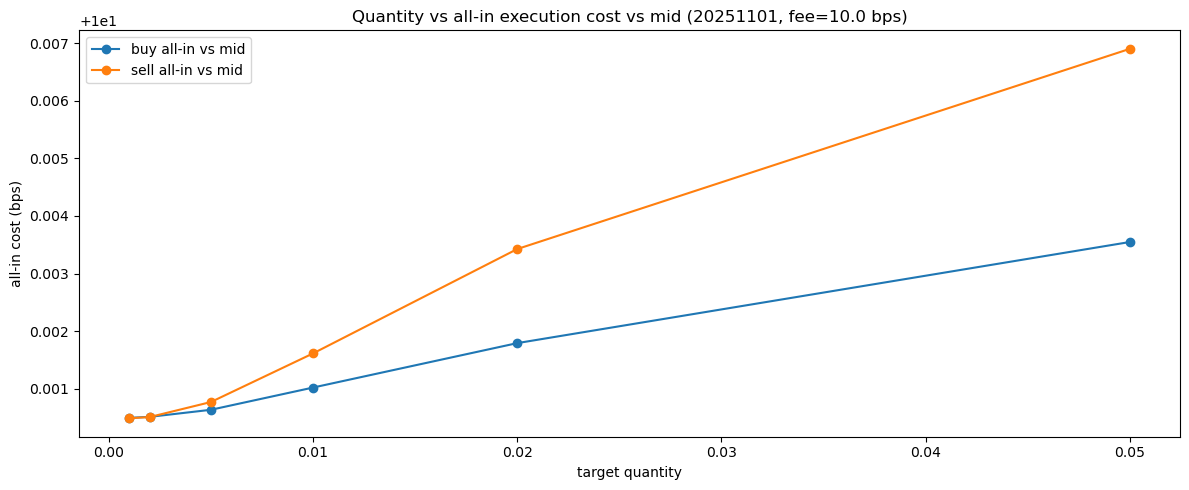

In [34]:
# =========================================
# 13d. Quantity vs all-in execution cost
# =========================================

fig, ax = plt.subplots(figsize=FIGSIZE)
ax.plot(
    buy_summary_richer["target_qty"],
    buy_summary_richer["avg_all_in_cost_vs_mid_bps"],
    marker="o",
    label="buy all-in vs mid",
)
ax.plot(
    sell_summary_richer["target_qty"],
    sell_summary_richer["avg_all_in_cost_vs_mid_bps"],
    marker="o",
    label="sell all-in vs mid",
)
ax.set_title(f"Quantity vs all-in execution cost vs mid ({TARGET_DATE}, fee={TAKER_FEE_BPS} bps)")
ax.set_xlabel("target quantity")
ax.set_ylabel("all-in cost (bps)")
ax.legend()
plt.tight_layout()
plt.show()

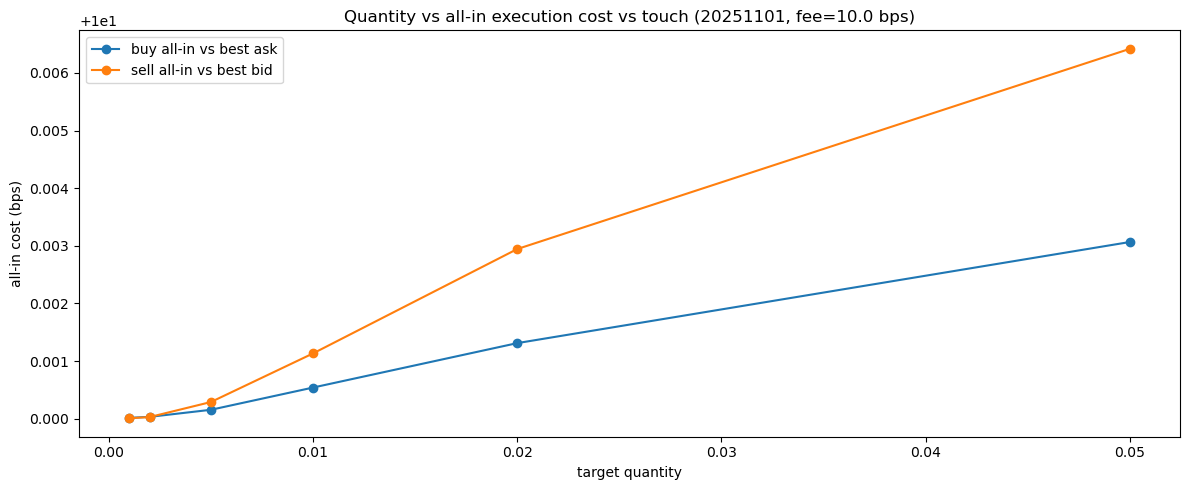

In [35]:
# =========================================
# 13e. Quantity vs all-in execution cost vs touch
# =========================================

fig, ax = plt.subplots(figsize=FIGSIZE)
ax.plot(
    buy_summary_richer["target_qty"],
    buy_summary_richer["avg_all_in_cost_vs_touch_bps"],
    marker="o",
    label="buy all-in vs best ask",
)
ax.plot(
    sell_summary_richer["target_qty"],
    sell_summary_richer["avg_all_in_cost_vs_touch_bps"],
    marker="o",
    label="sell all-in vs best bid",
)
ax.set_title(f"Quantity vs all-in execution cost vs touch ({TARGET_DATE}, fee={TAKER_FEE_BPS} bps)")
ax.set_xlabel("target quantity")
ax.set_ylabel("all-in cost (bps)")
ax.legend()
plt.tight_layout()
plt.show()

In [36]:
# =========================================
# 14. Fixed notional experiments
# =========================================

TEST_NOTIONALS = [100, 250, 500, 1000, 2500, 5000]

In [37]:
# =========================================
# 14b. Batch notional simulation
# =========================================

def run_taker_notional_experiments(
    df: pd.DataFrame,
    notionals: List[float],
    side: str = "buy",
    n: int = 20,
    max_rows: Optional[int] = None,
) -> pd.DataFrame:
    if max_rows is not None:
        df = df.iloc[:max_rows].copy()

    out = []

    for notional in notionals:
        for _, row in df.iterrows():
            if side == "buy":
                res = simulate_taker_buy_notional(row, notional=notional, n=n)
            elif side == "sell":
                res = simulate_taker_sell_notional(row, notional=notional, n=n)
            else:
                raise ValueError("side must be 'buy' or 'sell'")

            out.append(res)

    return pd.DataFrame(out)

buy_notional_results = run_taker_notional_experiments(
    df=EXPERIMENT_DF,
    notionals=TEST_NOTIONALS,
    side="buy",
    n=TOP_N,
)

sell_notional_results = run_taker_notional_experiments(
    df=EXPERIMENT_DF,
    notionals=TEST_NOTIONALS,
    side="sell",
    n=TOP_N,
)

buy_notional_results = add_fee_columns(buy_notional_results, side="buy", taker_fee_bps=TAKER_FEE_BPS)
sell_notional_results = add_fee_columns(sell_notional_results, side="sell", taker_fee_bps=TAKER_FEE_BPS)

print("buy_notional_results shape :", buy_notional_results.shape)
print("sell_notional_results shape:", sell_notional_results.shape)

buy_notional_results shape : (538338, 22)
sell_notional_results shape: (538338, 22)


In [38]:
# =========================================
# 14c. Notional summaries
# =========================================

def summarize_notional_results(results: pd.DataFrame, side: str) -> pd.DataFrame:
    grouped = results.groupby("target_notional")

    out = grouped.agg(
        n_obs=("target_notional", "size"),
        full_fill_rate=("fully_filled", "mean"),
        avg_target_qty=("target_qty", "mean"),
        avg_filled_qty=("filled_qty", "mean"),
        avg_fill_ratio=("fill_ratio", "mean"),
        avg_levels_swept=("n_levels_swept", "mean"),
        avg_slippage_vs_mid_bps=("slippage_vs_mid_bps", "mean"),
        avg_all_in_cost_vs_mid_bps=("all_in_cost_vs_mid_bps", "mean"),
    ).reset_index()

    out["side"] = side
    return out

buy_notional_summary = summarize_notional_results(buy_notional_results, side="buy")
sell_notional_summary = summarize_notional_results(sell_notional_results, side="sell")

display(buy_notional_summary)
display(sell_notional_summary)

,target_notional,n_obs,full_fill_rate,avg_target_qty,avg_filled_qty,avg_fill_ratio,avg_levels_swept,avg_slippage_vs_mid_bps,avg_all_in_cost_vs_mid_bps,side
0,100,89723,1.000000,0.000908,0.000908,1.000000,1.001126,0.000493,10.000493,buy
1,250,89723,1.000000,0.002271,0.002271,1.000000,1.004893,0.000518,10.000518,buy
2,500,89723,0.999989,0.004542,0.004542,0.999995,1.018256,0.000607,10.000607,buy
3,1000,89723,0.999989,0.009084,0.009084,0.999992,1.052618,0.000945,10.000945,buy
4,2500,89723,0.999320,0.022709,0.022706,0.999854,1.138571,0.001985,10.001985,buy
5,5000,89723,0.997236,0.045418,0.045376,0.999060,1.246659,0.003323,10.003323,buy


,target_notional,n_obs,full_fill_rate,avg_target_qty,avg_filled_qty,avg_fill_ratio,avg_levels_swept,avg_slippage_vs_mid_bps,avg_all_in_cost_vs_mid_bps,side
0,100,89723,1.000000,0.000908,0.000908,1.000000,1.001115,0.000487,10.000487,sell
1,250,89723,1.000000,0.002271,0.002271,1.000000,1.007813,0.000519,10.000519,sell
2,500,89723,1.000000,0.004542,0.004542,1.000000,1.035298,0.000711,10.000711,sell
3,1000,89723,0.999967,0.009084,0.009084,0.999992,1.113271,0.001438,10.001438,sell
4,2500,89723,0.998284,0.022709,0.022701,0.999650,1.291854,0.003840,10.003840,sell
5,5000,89723,0.994606,0.045418,0.045329,0.998027,1.474884,0.006483,10.006483,sell


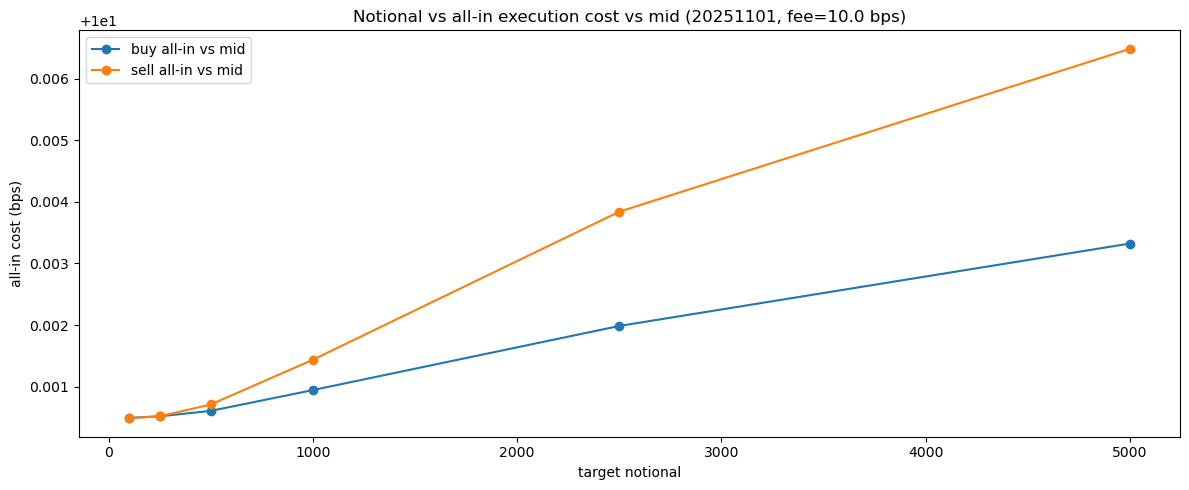

In [39]:
# =========================================
# 14d. Notional vs all-in cost
# =========================================

fig, ax = plt.subplots(figsize=FIGSIZE)
ax.plot(
    buy_notional_summary["target_notional"],
    buy_notional_summary["avg_all_in_cost_vs_mid_bps"],
    marker="o",
    label="buy all-in vs mid",
)
ax.plot(
    sell_notional_summary["target_notional"],
    sell_notional_summary["avg_all_in_cost_vs_mid_bps"],
    marker="o",
    label="sell all-in vs mid",
)
ax.set_title(f"Notional vs all-in execution cost vs mid ({TARGET_DATE}, fee={TAKER_FEE_BPS} bps)")
ax.set_xlabel("target notional")
ax.set_ylabel("all-in cost (bps)")
ax.legend()
plt.tight_layout()
plt.show()